In [6]:
from neuron import h
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from copy import deepcopy

In [7]:
h.load_file("main.hoc")
h.load_file("ampa_nmda_ltp.hoc")

1.0

# CNS 2025

Aušra is suggesting to investigate the **synaptic plasticity neuromodulation by TI during theta oscillations at hippocampal CA3- CA1 synapses**.

Steps:

1. Stimulate the synapses to induce LTP and LTD to select model parameters.

    According to Dainauskas et al. (2023):
    
    >
    > Synapses were stimulated at 100 Hz for 1 s (LTP protocol) or at 1 Hz for 500 s (LTD protocol) as in the study by Pousinha et al. (2017).
    >

2. Analyse effect of TI.

theta burst


## LTP protocol

In [8]:
def set_stimulus(delay = 100, duration = 900, frequency1 = 1000, frequency2 = 1005, amplitude = 100, phase = 0):
    h.setstim(delay, duration, frequency1, frequency2, amplitude, phase)

In [11]:
class Simulation:
    def __init__(self,
                 frequency1,
                 frequency2,
                 amplitude,
                 delay = 0,
                 duration = 3000,
                 n_synapses = 10,
                 ltp_start = 1000,
                 ltp_end = 2000
         ):
        self.frequency1 = frequency1
        self.frequency2 = frequency2
        self.amplitude = amplitude
        self.delay = delay
        self.duration = duration
        self.n_synapses = n_synapses
        self.ltp_start = ltp_start
        self.ltp_end = ltp_end
        
        self.is_ti = frequency1 != frequency2
        
        self.result = None
        self.synapse_weights = None

    def run_ltp_simulation(self):
        set_stimulus(
            delay = self.delay,
            duration = self.duration - self.delay,
            frequency1 = self.frequency1,
            frequency2 = self.frequency2,
            amplitude = self.amplitude,
            phase = 0
        )
    
        h.tstop = self.duration
    
        synapse_weights = []
        for i in range(self.n_synapses):
            syn_weight = h.Vector().record(h.syn_ampa[i]._ref_g)
            synapse_weights.append(syn_weight)
    
        soma = h.Vector().record(h.soma[0](0.5)._ref_v)
        t = h.Vector().record(h._ref_t)
    
        h.run()
    
        self.result = pd.DataFrame({
            "Time": t,
            "Soma": soma,
            "Frequency1": self.frequency1,
            "Frequency2": self.frequency2,
            "Amplitude": self.amplitude
        })
    
        result_syn = []
        for syn in synapse_weights:
            result_syn.append(deepcopy(np.array(syn)))
    
        self.synapse_weights = np.vstack(result_syn)
    
    def plot_result(self):
        fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 3.5))
        
        axs[0].plot(self.result.Time, self.result.Soma, label = "Soma", lw = 0.5, color = "black")
        axs[0].set_ylabel(r"$V_m$, mV")
        axs[0].set_xlabel("Time, ms")
        axs[0].set_ylim(-110, 70)
        axs[0].axvspan(
            self.ltp_start, self.ltp_end, alpha = 0.1,
            color = "orange",
            label = "LTP induction",
        )
        
        if self.is_ti:
            axs[0].set_title(rf"TI $\Delta f = {abs(int(self.frequency1 - self.frequency2))}$ Hz" + "\n" + rf"$E_0 = {self.amplitude}$ V/m")
        else:
            axs[0].set_title(rf"$f = {int(self.frequency1)}$ Hz" + "\n" + rf"$E_0 = {self.amplitude}$ V/m")
        
        for synapse in self.synapse_weights:
            axs[1].plot(self.result.Time, synapse, linewidth = 0.5)
        
        if self.is_ti:
            axs[1].set_title(rf"TI $\Delta f = {abs(int(self.frequency1 - self.frequency2))}$ Hz" + "\n" + rf"$E_0 = {self.amplitude}$ V/m")
        else:
            axs[1].set_title(rf"$f = {int(self.frequency1)}$ Hz" + "\n" + rf"$E_0 = {self.amplitude}$ V/m")
        
        # axs[1].set_ylim(-0.1, 1.1)
        
        axs[1].axvspan(
            self.ltp_start, self.ltp_end, alpha = 0.1,
            color = "orange",
            label = "LTP induction",
        )
        
        axs[1].set_xlabel("Time, ms")
        axs[1].set_ylabel("Synaptic strength")
        
        plt.tight_layout()

In [ ]:
simulation_nostim = Simulation(
    frequency1 = 0,
    frequency2 = 0,
    amplitude = 0
)

simulation_nostim.run_ltp_simulation()
simulation_nostim.plot_result()

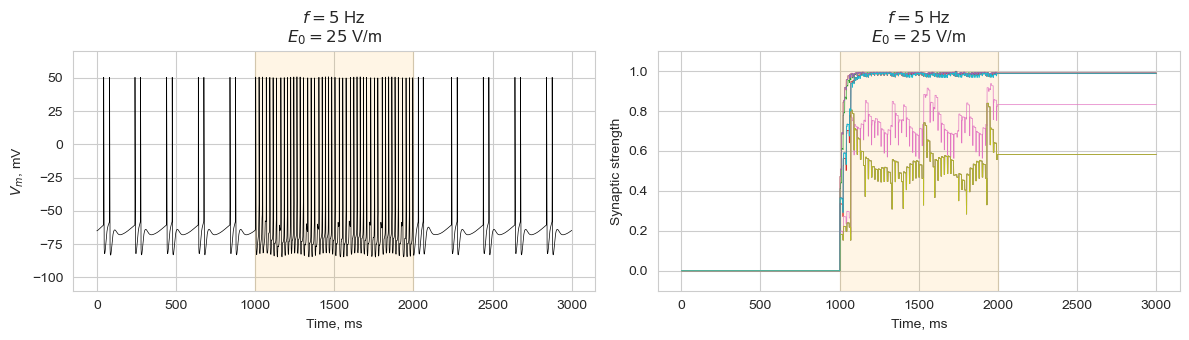

In [6]:
simulation_5hz = Simulation(
    frequency1 = 5,
    frequency2 = 5,
    amplitude = 25
)

simulation_5hz.run_ltp_simulation()
simulation_5hz.plot_result()

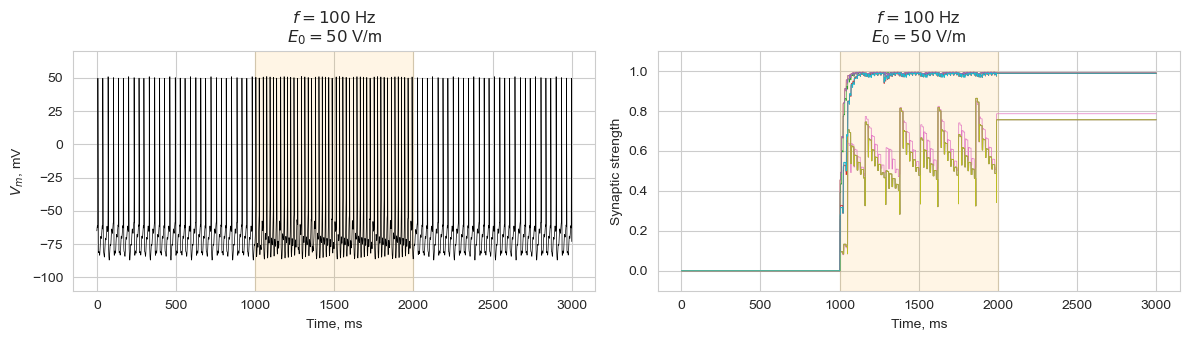

In [7]:
simulation_100hz = Simulation(
    frequency1 = 100,
    frequency2 = 100,
    amplitude = 50
)

simulation_100hz.run_ltp_simulation()
simulation_100hz.plot_result()

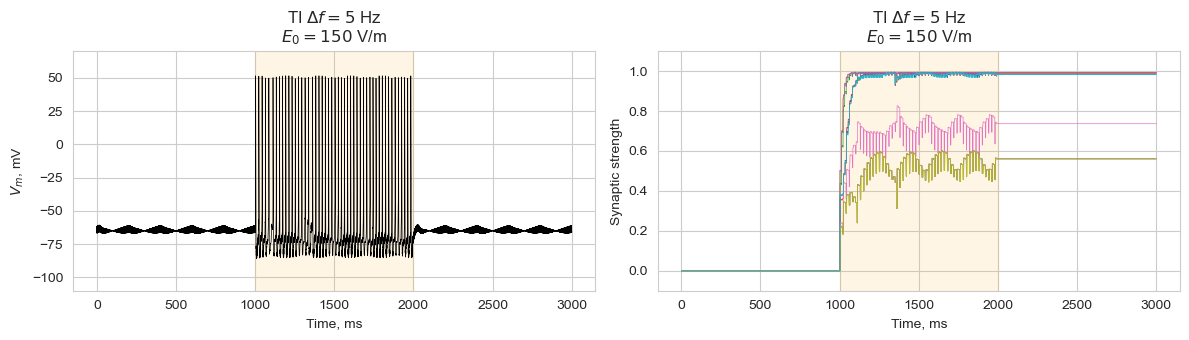

In [8]:
simulation_ti_5hz = Simulation(
    frequency1 = 1000,
    frequency2 = 1005,
    amplitude = 150
)

simulation_ti_5hz.run_ltp_simulation()
simulation_ti_5hz.plot_result()

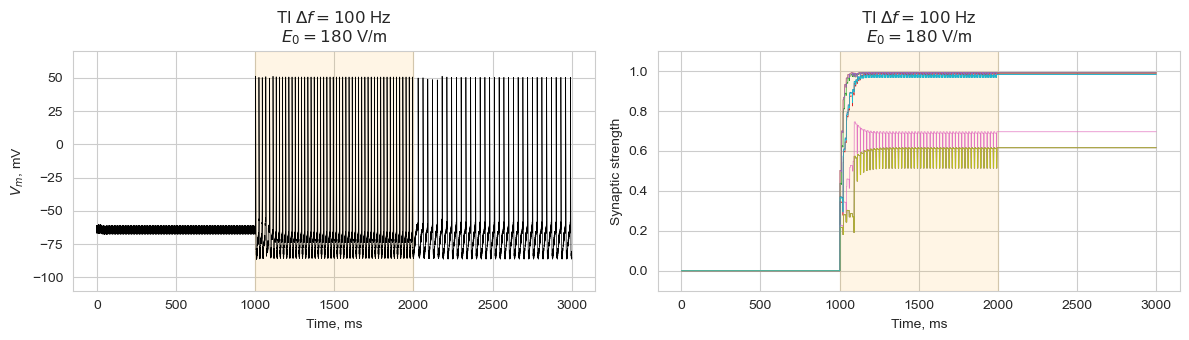

In [9]:
simulation_ti_100hz = Simulation(
    frequency1 = 1000,
    frequency2 = 1100,
    amplitude = 180
)

simulation_ti_100hz.run_ltp_simulation()
simulation_ti_100hz.plot_result()

TODO:
- excitatory post synaptic potential (EPSP) before and after stimulation
- should the start timing be different in different synapses?
- check: does the current flow through AMPA/NMDA channels during the stimulation?
- check: make sure the colors correspond to the same synapse
- why are some synapses potentiated fully and others not? does it depend on their location?
- how is the current synapse weight controlled? should it be set to a different value initially?

+ **run the simulation multiple times with randomized synapse locations**
+ determine minimum field strength that elicits APs
+ clean up code
+ run some stimulation before LTP onset

<pointer to hoc scalar 4.35576e-150>